In [7]:
import soundfile as sf
from IPython.display import Audio, display, Markdown
from hrtf import HRTF
from Trajectory import CircularTrajectory
from DynamicConvolver import DynamicConvolver
import numpy as np

# 1) Charger HRTF + signal
hrtf = HRTF.from_sofa("dataset/IRC_1002_C_44100.sofa")

#signal, sr = sf.read("impulse_repeated.wav")
#create a continus sinus signal 
duration = 10 # secondes
sr = 44100  # taux d'échantillonnage
facteur = 1/np.sqrt(100000) # pour éviter la saturation -3db

sinus_LA = np.zeros(sr*duration)
frequency = 440  # Fréquence du LA4

t = np.linspace(0, duration, sr*duration, endpoint=False)
sinus_LA = facteur * np.sin(2 * np.pi * frequency * t)  
sf.write("sinus_LA.wav", sinus_LA.astype(np.float32), sr)

audio_sinus_LA, sr = sf.read("sinus_LA.wav")

if audio_sinus_LA.ndim == 2:
    audio_sinus_LA = audio_sinus_LA.mean(axis=1)

# 2) Definir une trajectoire (exemple)
traj = CircularTrajectory(
    duration_s=len(audio_sinus_LA) / sr,
    period_s=3,
    elevation=0,
    start_az=0,
    clockwise=True,
 )

# 3) Convolution dynamique
conv = DynamicConvolver(
    hrtf=hrtf,
    signal=audio_sinus_LA,
    sr=sr,
    trajectory=traj,
    segment_ms=50,
    overlap_ms=10
 )

output = conv.run()  # np.ndarray shape (N, 2)

# 4) Sauvegarde (optionnel)
# conv.save("Left_dynamic.wav", "Right_dynamic.wav", "Merged_dynamic.wav")

# 5) Ecoute des 3 sorties
left = output[:, 0]
right = output[:, 1]

# Versions stereo pour ecouter chaque oreille separement au casque
left_only = np.stack([left, np.zeros_like(left)], axis=0)
right_only = np.stack([np.zeros_like(right), right], axis=0)
merged = output.T

display(Markdown("### Left (oreille gauche seule)"))
display(Audio(left_only, rate=sr, normalize=False))

display(Markdown("### Right (oreille droite seule)"))
display(Audio(right_only, rate=sr, normalize=False))

display(Markdown("### Merged (binaural stereo)"))
display(Audio(merged, rate=sr, normalize=False))

[SegmentEngine] Démarrage : 200 segments × 50 ms  |  overlap=10 ms  |  HRIR=512 smp  |  crossfade='cosine'
[SegmentEngine] Rendu terminé : 441511 échantillons (10.01s)


### Left (oreille gauche seule)

### Right (oreille droite seule)

### Merged (binaural stereo)

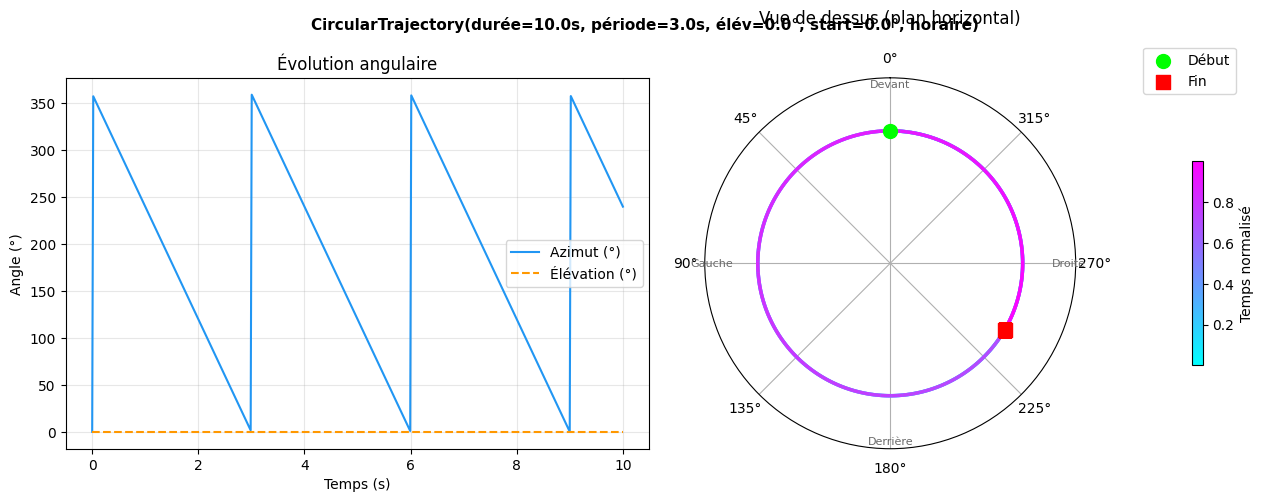

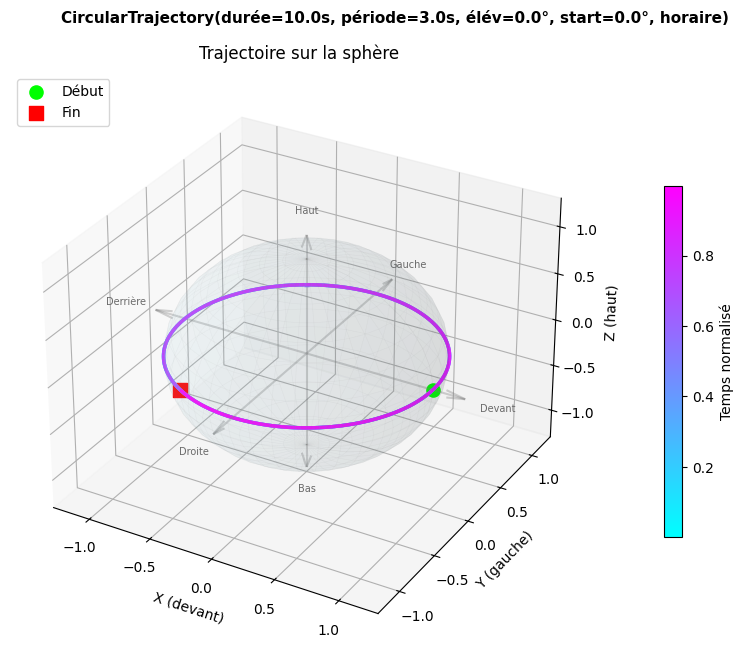

In [6]:
traj.plot_all()

In [ ]:
try:
    from Trajectory import RectilinearTrajectory
except ImportError:
    # Fallback local class if RectilinearTrajectory is not exposed in Trajectory.py
    class RectilinearTrajectory:
        def __init__(self, duration_s, start_az, start_el, end_az, end_el, R=1.0):
            self._duration = float(duration_s)
            self.start_az = float(start_az)
            self.start_el = float(start_el)
            self.end_az = float(end_az)
            self.end_el = float(end_el)
            self.R = float(R)

            p0 = self._sph_to_cart(self.start_az, self.start_el, self.R)
            p1 = self._sph_to_cart(self.end_az, self.end_el, self.R)

            u0 = p0 / np.linalg.norm(p0)
            u1 = p1 / np.linalg.norm(p1)
            dot = np.clip(np.dot(u0, u1), -1.0, 1.0)

            self.theta_deg = float(np.degrees(np.arccos(dot)))
            self.r_min = float(self.R * np.cos(np.radians(self.theta_deg / 2.0)))

            self._p0 = p0
            self._p1 = p1

        @staticmethod
        def _sph_to_cart(az_deg, el_deg, r):
            az = np.radians(az_deg)
            el = np.radians(el_deg)
            x = r * np.cos(el) * np.cos(az)
            y = r * np.cos(el) * np.sin(az)
            z = r * np.sin(el)
            return np.array([x, y, z], dtype=float)

        @staticmethod
        def _cart_to_sph(p):
            x, y, z = p
            r = np.linalg.norm(p)
            az = np.degrees(np.arctan2(y, x)) % 360.0
            el = np.degrees(np.arctan2(z, np.hypot(x, y)))
            return az, el, r

        def position(self, t):
            u = np.clip(t / self._duration, 0.0, 1.0)
            p = (1.0 - u) * self._p0 + u * self._p1
            return self._cart_to_sph(p)  # (az_deg, el_deg, r)

        def sample(self, t):
            return self.position(t)

        def __repr__(self):
            return (
                f"RectilinearTrajectory(durée={self._duration:.1f}s, "
                f"start=({self.start_az:.1f}°, {self.start_el:.1f}°), "
                f"end=({self.end_az:.1f}°, {self.end_el:.1f}°), "
                f"R={self.R:.2f}m, theta={self.theta_deg:.1f}°, r_min={self.r_min:.2f}m)"
            )

        def plot_all(self, n=400):
            import matplotlib.pyplot as plt

            tt = np.linspace(0, self._duration, int(n))
            vals = np.array([self.position(ti) for ti in tt])
            az, el, rr = vals[:, 0], vals[:, 1], vals[:, 2]

            fig, ax = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
            ax[0].plot(tt, az); ax[0].set_ylabel("Azimuth (°)"); ax[0].grid(True, alpha=0.3)
            ax[1].plot(tt, el); ax[1].set_ylabel("Elevation (°)"); ax[1].grid(True, alpha=0.3)
            ax[2].plot(tt, rr); ax[2].set_ylabel("Distance (m)"); ax[2].set_xlabel("Time (s)"); ax[2].grid(True, alpha=0.3)
            fig.tight_layout()
            plt.show()

# Corde de az=60° (avant-droite) → az=300° (avant-gauche)
# Les deux extrémités sont à R=2.06 m ; la corde passe devant à r_min ≈ 1.03 m
traj_rect = RectilinearTrajectory(
    duration_s = 5.0,
    start_az   = 60.0,   # avant-droit (60°)
    start_el   = 0.0,
    end_az     = 300.0,  # avant-gauche (300° ≡ −60°)
    end_el     = 0.0,
    R          = 2.06,   # rayon de la sphère HRTF (IRCAM LISTEN)
)

print(f"Angle entre extrémités  : {traj_rect.theta_deg:.1f}°")
print(f"Distance aux extrémités : {traj_rect.R:.2f} m")
print(f"Distance minimale       : {traj_rect.r_min:.2f} m  (à t = {traj_rect._duration/2:.1f} s)")
print()
print(traj_rect)

ImportError: cannot import name 'RectilinearTrajectory' from 'Trajectory' (c:\son_spatialisation\Trajectory.py)

In [ ]:
traj_rect.plot_all()
